# Credit Card Fraud Detection

Detecting fraudulent transactions using SMOTE, SVM, and XGBoost.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv("/content/credit_card_data/creditcard.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
fraud = df[df["Class"] == 1]

normal = df[df["Class"] == 0].sample(
    n=100000,
    random_state=42
)

df = pd.concat([normal, fraud]).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("New dataset shape:", df.shape)
print("\nClass distribution:")
print(df["Class"].value_counts())

New dataset shape: (100492, 31)

Class distribution:
Class
0    100000
1       492
Name: count, dtype: int64


In [ ]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

df.info()

Missing values: 0
Duplicate rows: 163
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100492 entries, 0 to 100491
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    100492 non-null  float64
 1   V1      100492 non-null  float64
 2   V2      100492 non-null  float64
 3   V3      100492 non-null  float64
 4   V4      100492 non-null  float64
 5   V5      100492 non-null  float64
 6   V6      100492 non-null  float64
 7   V7      100492 non-null  float64
 8   V8      100492 non-null  float64
 9   V9      100492 non-null  float64
 10  V10     100492 non-null  float64
 11  V11     100492 non-null  float64
 12  V12     100492 non-null  float64
 13  V13     100492 non-null  float64
 14  V14     100492 non-null  float64
 15  V15     100492 non-null  float64
 16  V16     100492 non-null  float64
 17  V17     100492 non-null  float64
 18  V18     100492 non-null  float64
 19  V19     100492 non-null  float64
 20  V20     10

Class
0    100000
1       492
Name: count, dtype: int64

Class percentage:
Class
0    99.5104
1     0.4896
Name: proportion, dtype: float64


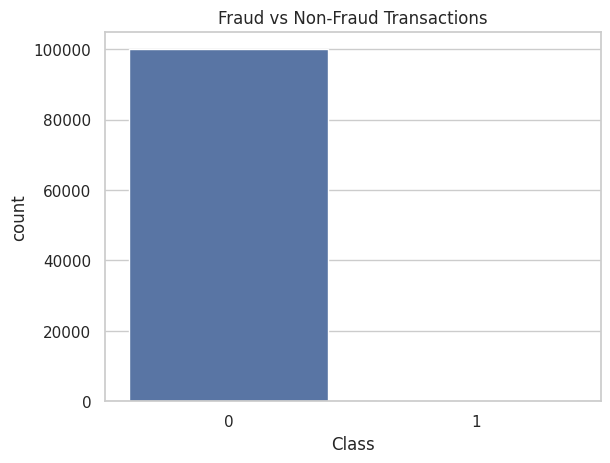

In [ ]:
print(df["Class"].value_counts())

print("\nClass percentage:")
print((df["Class"].value_counts(normalize=True) * 100).round(4))

sns.countplot(x="Class", data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (100329, 31)


In [ ]:
from google.colab import files

uploaded = files.upload()
zip_file = next(iter(uploaded))

print("Uploaded:", zip_file)

In [ ]:
import zipfile
import os

extract_path = "/content/credit_card_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

In [ ]:
import os

for root, dirs, files_list in os.walk("/content/credit_card_data"):
    for file in files_list:
        print(os.path.join(root, file))

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (100329, 30)
Target: (100329,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (80263, 30)
Testing set : (20066, 30)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling completed.")

Scaling completed.


In [ ]:
smote = SMOTE(
    sampling_strategy=0.20,
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    79885
1      378
Name: count, dtype: int64

After SMOTE:
Class
0    79885
1    15977
Name: count, dtype: int64


In [ ]:
svm_model = SVC(
    kernel="linear",
    probability=False,
    class_weight="balanced",
    random_state=42
)

svm_model.fit(X_train_smote, y_train_smote)

svm_pred = svm_model.predict(X_test_scaled)

svm_score = svm_model.decision_function(X_test_scaled)
svm_prob = 1 / (1 + np.exp(-svm_score))

In [ ]:
print("SVM RESULTS")
print("-" * 30)

print("Accuracy :", round(accuracy_score(y_test, svm_pred), 4))
print("Precision:", round(precision_score(y_test, svm_pred), 4))
print("Recall   :", round(recall_score(y_test, svm_pred), 4))
print("F1 Score :", round(f1_score(y_test, svm_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, svm_prob), 4))
print("PR-AUC   :", round(average_precision_score(y_test, svm_prob), 4))

SVM RESULTS
------------------------------
Accuracy : 0.974
Precision: 0.1462
Recall   : 0.9263
F1 Score : 0.2525
ROC-AUC  : 0.9778
PR-AUC   : 0.8362


In [ ]:
print(classification_report(
    y_test,
    svm_pred,
    target_names=["Normal", "Fraud"]
))

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     19971
       Fraud       0.15      0.93      0.25        95

    accuracy                           0.97     20066
   macro avg       0.57      0.95      0.62     20066
weighted avg       1.00      0.97      0.98     20066



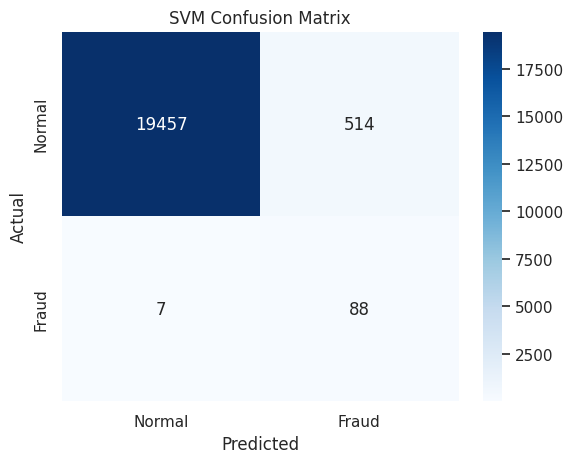

In [ ]:
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_smote, y_train_smote)

xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("XGBOOST RESULTS")
print("-" * 30)

print("Accuracy :", round(accuracy_score(y_test, xgb_pred), 4))
print("Precision:", round(precision_score(y_test, xgb_pred), 4))
print("Recall   :", round(recall_score(y_test, xgb_pred), 4))
print("F1 Score :", round(f1_score(y_test, xgb_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, xgb_prob), 4))
print("PR-AUC   :", round(average_precision_score(y_test, xgb_prob), 4))

XGBOOST RESULTS
------------------------------
Accuracy : 0.999
Precision: 0.9032
Recall   : 0.8842
F1 Score : 0.8936
ROC-AUC  : 0.9736
PR-AUC   : 0.8948


In [ ]:
print(classification_report(
    y_test,
    xgb_pred,
    target_names=["Normal", "Fraud"]
))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19971
       Fraud       0.90      0.88      0.89        95

    accuracy                           1.00     20066
   macro avg       0.95      0.94      0.95     20066
weighted avg       1.00      1.00      1.00     20066



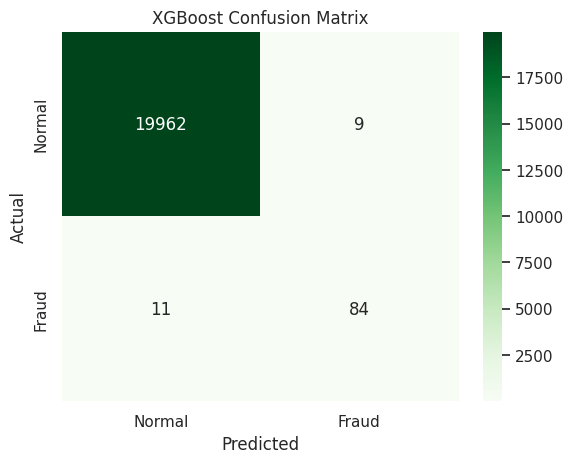

In [ ]:
cm = confusion_matrix(y_test, xgb_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["SVM", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, svm_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, svm_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, svm_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, svm_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, svm_prob),
        average_precision_score(y_test, xgb_prob)
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,SVM,0.974,0.1462,0.9263,0.2525,0.9778,0.8362
1,XGBoost,0.999,0.9032,0.8842,0.8936,0.9736,0.8948


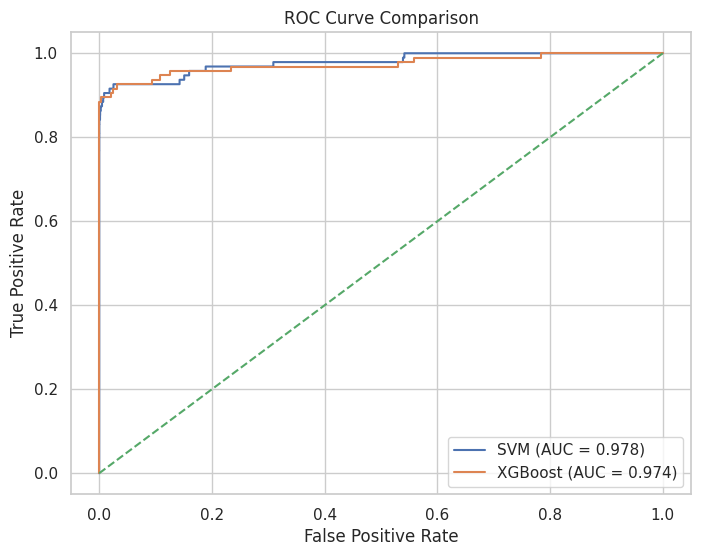

In [ ]:
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    svm_fpr,
    svm_tpr,
    label=f"SVM (AUC = {roc_auc_score(y_test, svm_prob):.3f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, xgb_prob):.3f})"
)

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

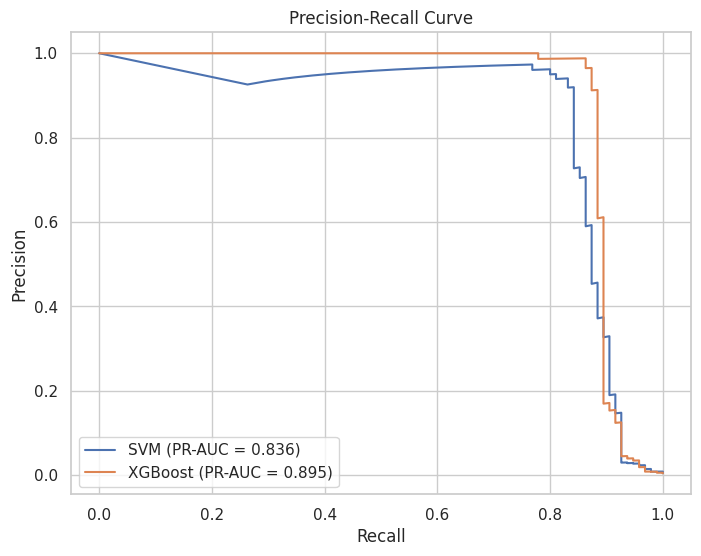

In [ ]:
svm_precision, svm_recall, _ = precision_recall_curve(
    y_test,
    svm_prob
)

xgb_precision, xgb_recall, _ = precision_recall_curve(
    y_test,
    xgb_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    svm_recall,
    svm_precision,
    label=f"SVM (PR-AUC = {average_precision_score(y_test, svm_prob):.3f})"
)

plt.plot(
    xgb_recall,
    xgb_precision,
    label=f"XGBoost (PR-AUC = {average_precision_score(y_test, xgb_prob):.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    pred = (xgb_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1 Score": f1_score(y_test, pred, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Precision,Recall,F1 Score
0,0.2,0.8000,0.8842,0.8400
1,0.3,0.8485,0.8842,0.8660
2,0.4,0.8660,0.8842,0.8750
3,0.5,0.9032,0.8842,0.8936
4,0.6,0.9121,0.8737,0.8925
5,0.7,0.9222,0.8737,0.8973


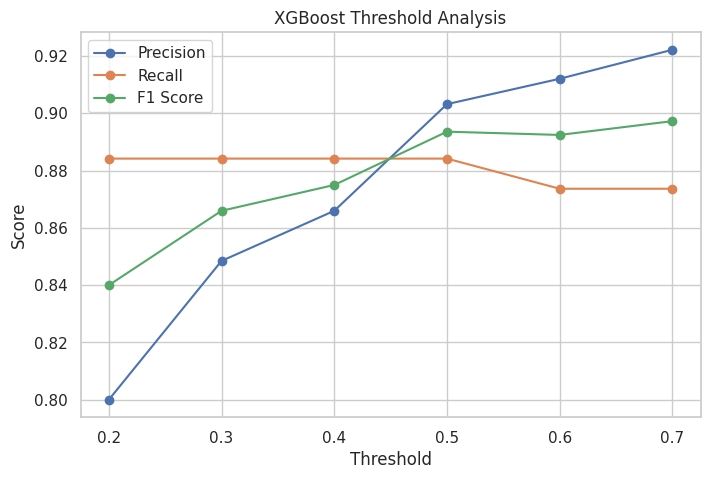

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Analysis")
plt.legend()
plt.show()

In [ ]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
display(importance.head(15))

Top 15 Important Features:


,0
V14,0.576242
V10,0.075263
V4,0.044041
V12,0.029096
V8,0.022053
V17,0.021431
V1,0.014142
V3,0.013566
Amount,0.012697
V18,0.012437


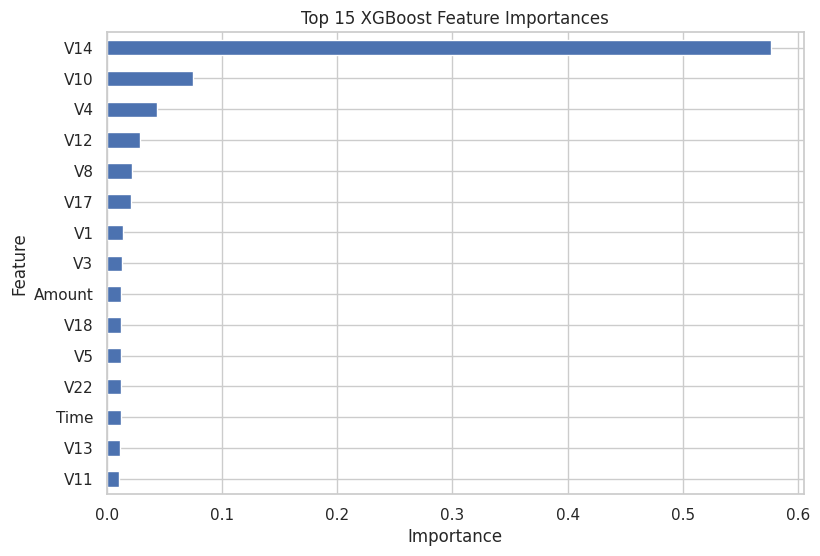

In [ ]:
plt.figure(figsize=(9, 6))

importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")
plt.show()

In [ ]:
final_threshold = 0.50

final_pred = (xgb_prob >= final_threshold).astype(int)

print("Final XGBoost Performance")
print("-" * 35)

print("Accuracy :", round(accuracy_score(y_test, final_pred), 4))
print("Precision:", round(precision_score(y_test, final_pred), 4))
print("Recall   :", round(recall_score(y_test, final_pred), 4))
print("F1 Score :", round(f1_score(y_test, final_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, xgb_prob), 4))
print("PR-AUC   :", round(average_precision_score(y_test, xgb_prob), 4))

Final XGBoost Performance
-----------------------------------
Accuracy : 0.999
Precision: 0.9032
Recall   : 0.8842
F1 Score : 0.8936
ROC-AUC  : 0.9736
PR-AUC   : 0.8948


## Conclusion

XGBoost was trained to detect fraudulent credit card transactions after
handling class imbalance using SMOTE.

The models were evaluated using:
- Precision
- Recall
- F1 Score
- ROC-AUC
- PR-AUC
- Confusion Matrix

Threshold tuning was used to study the trade-off between detecting more
fraudulent transactions and reducing false alarms.

Feature importance was also analyzed using XGBoost.